In [ ]:
!pip install scikit-learn


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving legal_docs_large.csv to legal_docs_large.csv


In [ ]:
import pandas as pd
df = pd.read_csv("legal_docs_large.csv")
df


,document_summary,actual_type
0,An agreement between two parties for providing...,Service Agreement
1,Document detailing employee's obligation not t...,Non-Disclosure Agreement
2,This contract outlines payment terms and scope...,Contract
3,An NDA for a vendor working with proprietary c...,Non-Disclosure Agreement
4,Agreement for regular system maintenance and s...,Service Agreement
5,Memorandum of understanding for joint marketin...,Contract
6,Contract for web development and hosting for a...,Contract
7,Non-disclosure agreement signed before discuss...,Non-Disclosure Agreement
8,Data sharing agreement between two healthcare ...,Data Sharing Agreement
9,Legal terms for outsourcing customer support o...,Service Agreement


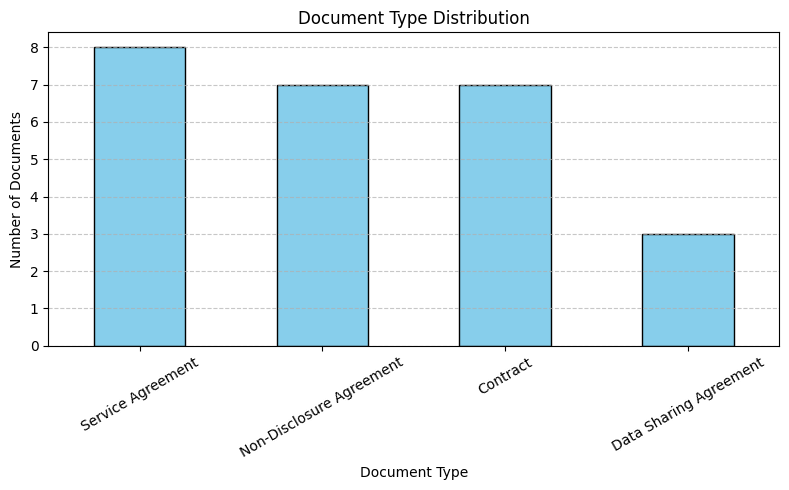

In [ ]:
import matplotlib.pyplot as plt
type_counts = df['actual_type'].value_counts()
plt.figure(figsize=(8, 5))
type_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Document Type Distribution")
plt.xlabel("Document Type")
plt.ylabel("Number of Documents")
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

X = df["document_summary"]
y = df["actual_type"]

vectorizer = TfidfVectorizer()
X_vectorized = vectorizer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized, y, test_size=0.3, random_state=42
)


In [ ]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)


MultinomialNB()

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.375

Classification Report:
                           precision    recall  f1-score   support

                Contract       0.00      0.00      0.00         1
  Data Sharing Agreement       0.00      0.00      0.00         2
Non-Disclosure Agreement       0.00      0.00      0.00         2
       Service Agreement       0.75      1.00      0.86         3

                accuracy                           0.38         8
               macro avg       0.19      0.25      0.21         8
            weighted avg       0.28      0.38      0.32         8



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
def classify_new_summary(summary):
    summary_vector = vectorizer.transform([summary])
    prediction = model.predict(summary_vector)
    return prediction[0]

new_summary = "This agreement ensures parties cannot share confidential information."
print("Predicted Document Type:", classify_new_summary(new_summary))


Predicted Document Type: Contract
